# Statistical Inference of Subjective Preferences

**Notebook 2 of 2 — Statistical Inference of Subjective Preferences from Choices Under Uncertainty**

This notebook uses the cleaned choice data produced in Notebook 1
(`data/processed/choices_clean.csv`) to address the research questions directly. As a
reminder, the dataset is **simulated**; results below describe properties of a
simulation designed to have realistic qualitative features, not empirical facts about
real decision-makers. The statistical methods themselves, and the reasoning about what
they can and cannot establish, are the actual content of this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import log_loss, accuracy_score
import sys, os

sys.path.insert(0, os.path.join("..", "src"))
from analysis_helpers import (
    approximate_certainty_equivalent, classify_switching, cluster_bootstrap_ci,
)

FIG_DIR = os.path.join("..", "figures")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv(os.path.join("..", "data", "processed", "choices_clean.csv"))
substantive = df[~df.is_dominance_check].copy()
substantive["gambled"] = (substantive.choice == "gamble").astype(int)
dom_checks = df[df.is_dominance_check].copy()
dom_checks["gambled"] = (dom_checks.choice == "gamble").astype(int)

print(f"Participants: {df.participant_id.nunique()}")
print(f"Substantive trials: {len(substantive)}   Dominance-check trials: {len(dom_checks)}")

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\processed\\choices_clean.csv'

## 1. Descriptive Statistics

In [ ]:
summary = pd.DataFrame({
    "n_trials": substantive.groupby("domain").size(),
    "acceptance_rate": substantive.groupby("domain").gambled.mean(),
    "sd": substantive.groupby("domain").gambled.std(),
}).round(3)
print(summary)

print("\nAcceptance by probability and domain:")
print(substantive.groupby(["domain", "probability"]).gambled.mean().unstack("domain").round(3))

print("\nDominance-check gamble rate by domain (attentiveness marker):")
print(dom_checks.groupby("domain").gambled.mean().round(3))

print("\nParticipant-level acceptance rate, gain domain:")
print(substantive[substantive.domain == "gain"].groupby("participant_id").gambled.mean().describe().round(3))

        n_trials  acceptance_rate     sd
domain                                  
gain         885            0.547  0.498
loss         883            0.454  0.498

Acceptance by probability and domain:
domain        gain   loss
probability              
0.10         0.522  0.388
0.25         0.551  0.475
0.50         0.551  0.454
0.75         0.572  0.461
0.90         0.537  0.494

Dominance-check gamble rate by domain (attentiveness marker):
domain
gain    0.100
loss    0.034
Name: gambled, dtype: float64

Participant-level acceptance rate, gain domain:
count    60.000
mean      0.547
std       0.164
min       0.200
25%       0.400
50%       0.533
75%       0.667
max       0.867
Name: gambled, dtype: float64


## 2. Individual Choice Patterns

For each participant, probability level, and domain, there are three certain-amount
observations bracketing the expected value. If a participant's preferences are stable
and the certain amount is genuinely the only thing that matters (holding probability and
domain fixed), then as the certain option becomes objectively more attractive we should
see *at most one* switch from the risky to the certain option — never the reverse. Three
or more such crossings-worth of data per triple is not much to check consistency with,
but a clear pattern of repeated reversals is still informative.

Each triple is classified as `always_gamble`, `never_gamble`, `single_switch` (a clean,
single crossing), `non_monotonic` (a reversal — the participant preferred the gamble
at an objectively worse certain amount than one where they took the certain option), or
`incomplete` (fewer than 3 brackets survived the Notebook 1 cleaning step for that
triple — classifying these from partial data would rest on less evidence than the label
implies, so they are reported separately and excluded from the consistency calculation
below).

In [ ]:
triples = (substantive[~substantive.is_dominance_check]
           .groupby(["participant_id", "domain", "probability"]))
patterns = triples.apply(classify_switching, include_groups=False).rename("pattern").reset_index()

print(patterns.pattern.value_counts(normalize=True).round(3))
n_incomplete = (patterns.pattern == "incomplete").sum()
print(f"\n{n_incomplete} of {len(patterns)} triples were incomplete (fewer than 3 "
      f"brackets survived cleaning in Notebook 1, Section 7) and are excluded below "
      f"rather than classified from partial data.")

determinate = patterns[patterns.pattern != "incomplete"].copy()
determinate["consistent"] = determinate.pattern != "non_monotonic"
consistency = determinate.groupby("participant_id").consistent.mean()
print(f"\nParticipant-level share of internally-consistent triples (among determinate "
      f"triples only): mean={consistency.mean():.3f}, min={consistency.min():.3f}, "
      f"max={consistency.max():.3f}")

# Relationship (descriptive only) between dominance-check failures and non-monotonic choice
dom_fail_rate = dom_checks.groupby("participant_id").gambled.mean().rename("dominance_violation_rate")
merged = pd.concat([consistency.rename("consistency"), dom_fail_rate], axis=1)
print(f"\nCorrelation between consistency and dominance-check violation rate: "
      f"{merged.consistency.corr(merged.dominance_violation_rate):.3f}")

pattern
single_switch    0.512
non_monotonic    0.202
always_gamble    0.125
never_gamble     0.108
incomplete       0.053
Name: proportion, dtype: float64

32 of 600 triples were incomplete (fewer than 3 brackets survived cleaning in Notebook 1, Section 7) and are excluded below rather than classified from partial data.

Participant-level share of internally-consistent triples (among determinate triples only): mean=0.787, min=0.444, max=1.000

Correlation between consistency and dominance-check violation rate: -0.248


Most triples show either a single, clean switch or a corner pattern (always/never
gambling within that triple), which is the behaviour a stable underlying preference would
produce. A minority are non-monotonic. This is treated as **evidence of imperfect
attention or measurement noise**, not automatically as "mistakes" in a normative
sense — with only three points per triple, a single misclick or momentary lapse in
attention is enough to produce a reversal, and the design offers no way to distinguish
that from a genuinely unstable preference. The modest negative correlation with the
dominance-check violation rate is consistent with (though far from proof of) a shared
"attentiveness" factor underlying both.

## 3. Certainty Equivalents

Where a participant's choices at a given probability and domain show a single clean
switch, an approximate **certainty equivalent (CE)** can be read off as the midpoint
between the last certain amount at which they still chose the gamble and the first at
which they chose the certain option. This is a coarse, three-point approximation — not
an exact measurement — and is left undefined (`NaN`) whenever the triple was
`always_gamble`, `never_gamble`, or `non_monotonic`, rather than forcing an estimate
where the data do not support one.

Share of triples with an estimable single-switch CE: 0.512


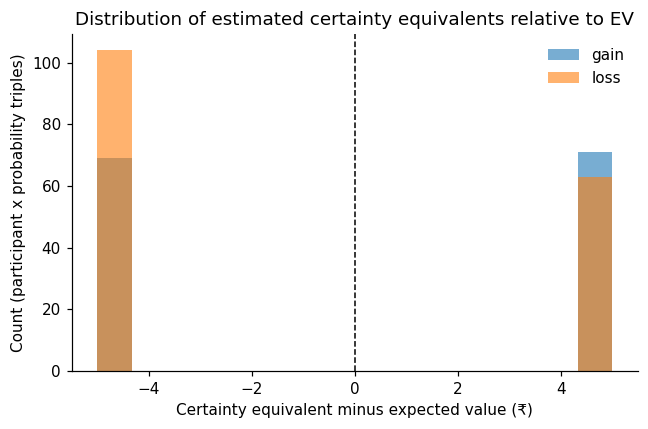

        mean  median   std  count
domain                           
gain    0.07     5.0  5.02    140
loss   -1.23    -5.0  4.86    167


In [ ]:
ce = triples.apply(approximate_certainty_equivalent, include_groups=False).rename("CE").reset_index()
ce["ev_signed"] = np.where(ce.domain == "gain", ce.probability * 100, -ce.probability * 100)
ce["ce_minus_ev"] = ce.CE - ce.ev_signed

n_estimable = ce.CE.notna().mean()
print(f"Share of triples with an estimable single-switch CE: {n_estimable:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
for dom, color in [("gain", "tab:blue"), ("loss", "tab:orange")]:
    vals = ce.loc[ce.domain == dom, "ce_minus_ev"].dropna()
    ax.hist(vals, bins=15, alpha=0.6, label=dom, color=color)
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Certainty equivalent minus expected value (₹)")
ax.set_ylabel("Count (participant x probability triples)")
ax.set_title("Distribution of estimated certainty equivalents relative to EV")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_certainty_equivalent_distribution.png"))
plt.show()

print(ce.groupby("domain").ce_minus_ev.agg(["mean", "median", "std", "count"]).round(2))

**Reading this figure requires care because of the domain reflection noted in
Section 8 below.** In the gain domain, a negative `CE − EV` means the
participant needed *less* than the fair value to give up the gamble — the standard
signature of risk aversion. In the loss domain, the analogous signature of risk aversion
is the *opposite* sign: a participant who is averse to the loss lottery will only keep
gambling if the guaranteed loss on offer is worse than fair value, so a risk-averse
loss-domain CE sits *above* (less negative than) the EV. A negative-only reading of
"CE − EV" for both panels, without this adjustment, would silently misclassify one
domain.

With that adjustment made, the two domains look different from each other **and**
different from the simplest textbook expectation. The gain-domain distribution here is
close to a 50/50 split between the risk-averse and risk-seeking sides (mean ≈ ₹0.1,
essentially no net tilt at this coarse three-point resolution), while the loss-domain
distribution leans toward the risk-averse-consistent side (mean ≈ −₹1.2, roughly 62% of
estimable triples on that side) — the *opposite* pattern from the classic "reflection
effect" (risk-averse for gains, risk-seeking for losses) that a stylised prospect-theory
account would predict. This is a legitimate feature of this particular simulated
population's realised parameter draws, not an error: a simulation with individual
heterogeneity need not reproduce every textbook regularity exactly, any more than a real
sample would. This asymmetry, and the aggregate acceptance-rate gap it relates to, is
examined further in Sections 4 and 7 below.

## 4. Statistical Uncertainty

Trials from the same participant are not independent observations — a participant with
a generally high risk tolerance will tend to gamble more across many trials. Standard
errors and confidence intervals that treated every trial as independent would be too
narrow. Throughout this notebook, uncertainty is quantified with a **cluster bootstrap**
that resamples *participants* (with replacement), not trials, so that all of a
resampled participant's trials move together — this preserves the within-participant
dependence in the resampling scheme (`cluster_bootstrap_ci` in `src/analysis_helpers.py`).

Two quantities are estimated here: the overall gain- and loss-domain acceptance rates,
and the gain-minus-loss difference. A paired test (participants contribute one
observation to each domain) is also reported as a complementary, model-free check.

In [ ]:
gain_df = substantive[substantive.domain == "gain"]
loss_df = substantive[substantive.domain == "loss"]

gain_mean, gain_lo, gain_hi = cluster_bootstrap_ci(gain_df, "participant_id", lambda d: d.gambled.mean())
loss_mean, loss_lo, loss_hi = cluster_bootstrap_ci(loss_df, "participant_id", lambda d: d.gambled.mean())

def gain_minus_loss(d):
    g = d[d.domain == "gain"].gambled.mean()
    l = d[d.domain == "loss"].gambled.mean()
    return g - l

diff_mean, diff_lo, diff_hi = cluster_bootstrap_ci(substantive, "participant_id", gain_minus_loss)

print(f"Gain acceptance:        {gain_mean:.3f}  95% CI [{gain_lo:.3f}, {gain_hi:.3f}]")
print(f"Loss acceptance:        {loss_mean:.3f}  95% CI [{loss_lo:.3f}, {loss_hi:.3f}]")
print(f"Gain minus loss:        {diff_mean:.3f}  95% CI [{diff_lo:.3f}, {diff_hi:.3f}]")

paired = (substantive.groupby(["participant_id", "domain"]).gambled.mean()
          .unstack("domain"))
t_stat, t_p = stats.ttest_rel(paired["gain"], paired["loss"])
w_stat, w_p = stats.wilcoxon(paired["gain"], paired["loss"])
print(f"\nPaired t-test (gain vs loss, n={len(paired)}): t={t_stat:.2f}, p={t_p:.4f}")
print(f"Wilcoxon signed-rank (robustness check):        W={w_stat:.1f}, p={w_p:.4f}")

Gain acceptance:        0.548  95% CI [0.506, 0.590]
Loss acceptance:        0.453  95% CI [0.411, 0.497]
Gain minus loss:        0.094  95% CI [0.018, 0.172]

Paired t-test (gain vs loss, n=60): t=2.40, p=0.0196
Wilcoxon signed-rank (robustness check):        W=552.5, p=0.0452


**What this estimates.** The cluster-bootstrap intervals describe uncertainty
about the *population* acceptance rate implied by this participant sample, accounting
for within-participant correlation. The paired test asks a narrower, model-free
question: within this sample, is the average within-participant gap between gain- and
loss-domain acceptance different from zero? **Assumptions**: the bootstrap assumes
participants are drawn independently from some population (reasonable for the
recruitment design, not verifiable from the data itself); the paired t-test additionally
assumes the within-participant differences are reasonably close to normally distributed,
which is why the non-parametric Wilcoxon test is reported alongside it as a check.

## 5. Statistical Choice Model

The outcome is $Y_i = 1$ if the risky option was chosen on trial $i$, $0$ otherwise. A
logistic regression models

$$P(Y_i = 1) = \text{logit}^{-1}(\beta_0 + \beta_1 \, p_i + \beta_2 \, \text{gen}_i + \beta_3\, \text{loss}_i + \beta_4\, (p_i \times \text{loss}_i) + \beta_5\, (\text{gen}_i \times \text{loss}_i))$$

`gen` ("generosity") measures how much better the certain option is than the lottery's
expected value, in rupees, **defined consistently across domains**: it equals
`certain_amount - EV` in the gain domain, and `EV - certain_amount` in the loss domain
(a smaller guaranteed loss counts as "more generous"). This distinction matters. The raw
design variable recorded during data collection, `certain_offset`, is the offset used to
*construct* each certain amount (Notebook 1, Section 5) — but because the certain amount
is built as `EV + offset` for gains and as `-(EV + offset)` for losses, the same
`certain_offset` value means "more generous" in the gain domain and "less generous" in
the loss domain. Using it directly in a single pooled model would make the domain
interaction term partly an artefact of that sign flip rather than a genuine behavioural
comparison. `gen` corrects for this so that the coefficient on `gen` and its interaction
with `loss` isolate an actual behavioural question — does sensitivity to how the certain
option compares to the EV differ between domains? — rather than a labelling artefact.
Standard errors are clustered by participant, for the same reason given in Section 4.
Dominance-check trials are excluded (they were designed to be answered in an unambiguous
way and are not part of the substantive design).

In [ ]:
model_df = substantive.copy()
model_df["loss"] = (model_df.domain == "loss").astype(int)
model_df["gen"] = np.where(model_df.domain == "gain",
                            model_df.certain_offset, -model_df.certain_offset)

logit = smf.logit("gambled ~ probability + gen + loss "
                   "+ probability:loss + gen:loss", data=model_df)
fit = logit.fit(cov_type="cluster", cov_kwds={"groups": model_df["participant_id"]}, disp=False)
print(fit.summary())

                           Logit Regression Results                           
Dep. Variable:                gambled   No. Observations:                 1768
Model:                          Logit   Df Residuals:                     1762
Method:                           MLE   Df Model:                            5
Date:                Wed, 12 Aug 2026   Pseudo R-squ.:                  0.1348
Time:                        09:50:19   Log-Likelihood:                -1060.3
converged:                       True   LL-Null:                       -1225.5
Covariance Type:              cluster   LLR p-value:                 3.076e-69
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.1573      0.174      0.905      0.366      -0.184       0.498
probability          0.1194      0.243      0.491      0.623      -0.357       0.596
gen                 -0.0943 

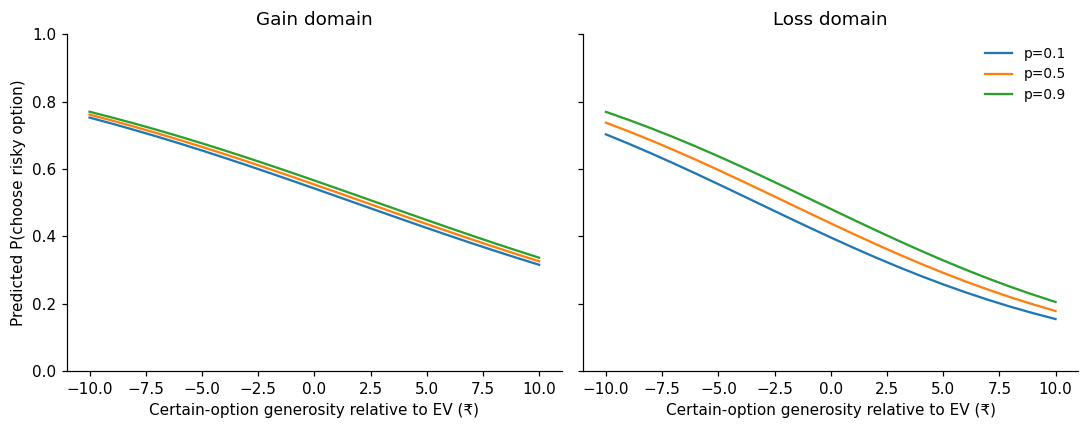

In [ ]:
# Predicted-probability plot: easier to interpret than raw coefficients
grid = pd.DataFrame([
    {"probability": p, "gen": g, "loss": loss}
    for p in [0.1, 0.5, 0.9]
    for g in np.linspace(-10, 10, 21)
    for loss in [0, 1]
])
grid["pred"] = fit.predict(grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, loss_val, title in zip(axes, [0, 1], ["Gain domain", "Loss domain"]):
    sub = grid[grid.loss == loss_val]
    for p in [0.1, 0.5, 0.9]:
        s = sub[sub.probability == p]
        ax.plot(s.gen, s.pred, label=f"p={p}")
    ax.set_title(title)
    ax.set_xlabel("Certain-option generosity relative to EV (₹)")
    ax.set_ylim(0, 1)
axes[0].set_ylabel("Predicted P(choose risky option)")
axes[1].legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_predicted_probabilities.png"))
plt.show()

**Interpretation, not just significance.** The `gen` coefficient is the most
directly interpretable: holding probability and domain fixed, it captures how sensitive
gambling is to the certain option's generosity relative to the lottery's EV, in the gain
domain. Its interaction with `loss` asks whether that sensitivity is genuinely different
in the loss domain — not merely a labelling artefact of how the trial was constructed
(see the note above on why `gen`, not the raw design offset, is used here). The
predicted-probability curves make this concrete without requiring the reader to combine
several coefficients mentally: if the two panels show similarly-sloped, similarly-shaped
curves, that is evidence *against* a domain-specific difference in sensitivity to the
certain option's generosity, beyond the overall gain/loss shift already captured by the
`loss` main effect. Statistical significance of individual coefficients is reported for
completeness, but the predicted-probability plot is the primary basis for interpretation
here, per the project's emphasis on substantive rather than purely statistical
significance.

## 6. Heterogeneity

Section 1's descriptive table and Notebook 1's histogram both show participant-level
acceptance rates spread out rather than clustered tightly around one value. That is
consistent with genuine preference heterogeneity, but it is also exactly what pure
sampling noise would produce even if every participant secretly shared the same
underlying acceptance probability — each participant's *observed* rate is based on only
15 trials per domain. A useful check is to compare the **observed between-participant
variance** in acceptance rates to the variance we would expect under a null of "everyone
shares one true rate," obtained by simulation.

Observed between-participant variance (gain domain): 0.02673
Expected variance under 'one shared rate' null:      0.01650
One-sided simulation p-value (observed >= null):     0.0010


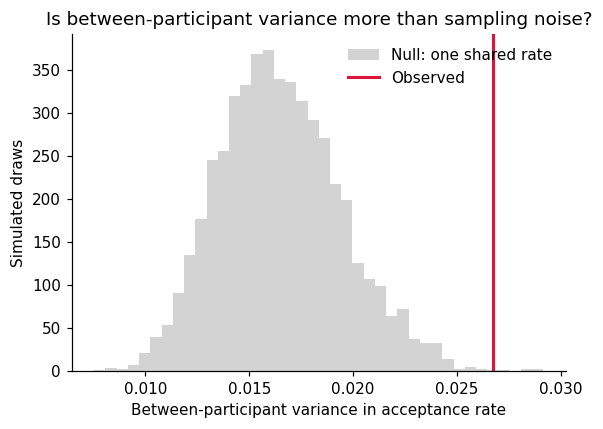

In [ ]:
def observed_variance(rates):
    return rates.var(ddof=1)

gain_rates = substantive[substantive.domain == "gain"].groupby("participant_id").gambled.mean()
n_trials_per_p = substantive[substantive.domain == "gain"].groupby("participant_id").size().mean()
pooled_rate = gain_rates.mean()
obs_var = observed_variance(gain_rates)

rng = np.random.default_rng(42)
n_sims = 5000
null_vars = np.empty(n_sims)
n_participants = len(gain_rates)
n_trials = int(round(n_trials_per_p))
for s in range(n_sims):
    sim_rates = rng.binomial(n_trials, pooled_rate, size=n_participants) / n_trials
    null_vars[s] = sim_rates.var(ddof=1)

p_value = (null_vars >= obs_var).mean()
print(f"Observed between-participant variance (gain domain): {obs_var:.5f}")
print(f"Expected variance under 'one shared rate' null:      {null_vars.mean():.5f}")
print(f"One-sided simulation p-value (observed >= null):     {p_value:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.hist(null_vars, bins=40, color="lightgray", label="Null: one shared rate")
ax.axvline(obs_var, color="crimson", lw=2, label="Observed")
ax.set_xlabel("Between-participant variance in acceptance rate")
ax.set_ylabel("Simulated draws")
ax.set_title("Is between-participant variance more than sampling noise?")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_heterogeneity_overdispersion_test.png"))
plt.show()

**Reading the result.** The observed between-participant variance sits clearly above
the bulk of the simulated null distribution (one-sided simulated $p = 0.001$): the spread
visible in the raw histogram (Notebook 1, Section 8) is **not plausibly explained by
15-trial sampling noise alone**. This is evidence of genuine heterogeneity in gamble
acceptance across participants, over and above what a single shared response
probability would produce.

This is a different conclusion from a simpler eyeball reading of the histogram, and that
distinction is the point of running the test at all: a spread-out histogram is only
suggestive on its own, since sampling noise alone can also spread out a histogram at this
sample size. Here, the observed spread turns out to be larger than that noise floor by
a comfortable margin, which is what justifies calling it heterogeneity rather than
noise. The test does not, however, say anything about the *number* of distinct
preference types or their individual values — only that a single shared rate is not a
statistically adequate description of these participants.

This approach — a simulation-based overdispersion test — was chosen deliberately over
fitting a full hierarchical (random-effects) logistic model: with 60 participants and 15
substantive trials per domain each, a random-effects model would be estimable in
principle but its variance-component estimate would itself be quite uncertain, and a
simpler, more transparent test is preferable at this sample size. **This is stated
explicitly rather than glossed over**: a richer characterisation of *how* preferences
vary (e.g. separate per-participant risk parameters with proper uncertainty intervals)
is not reliably supportable with this sample size and is not attempted, even though the
present, coarser test finds evidence that such variation exists.

Section 7 revisits this decision directly and fits a random-intercept model anyway, as
an independent cross-check rather than a reversal of this reasoning. The distinction
that matters turns out to be between a random *intercept* (estimable here) and random
*slopes* or individual-level parameters (still not reliably estimable at this sample
size, and still not attempted).

## 7. Heterogeneity, Formally: A Random-Intercept Model

Section 6 deliberately used a simulation-based overdispersion test rather than a
hierarchical (random-effects) logistic model, reasoning that with 60 participants and 15
substantive trials per domain each, a variance-component estimate would itself carry a
lot of uncertainty. That reasoning was about whether a hierarchical model would be
*informative*, not whether it would *run* — and the two questions can have different
answers. This section fits the model anyway, as a second, independent check on the same
question rather than a replacement for Section 6: if two methods with different
assumptions and different failure modes agree that heterogeneity is present, that is
stronger evidence than either alone.

The model adds a participant-level random intercept to the Section 5 specification:

$$P(Y_i = 1) = \text{logit}^{-1}\big(\beta_0 + u_{j(i)} + \beta_1 p_i + \beta_2\,\text{gen}_i + \beta_3\,\text{loss}_i + \beta_4\,(p_i \times \text{loss}_i) + \beta_5\,(\text{gen}_i \times \text{loss}_i)\big), \qquad u_j \sim N(0, \sigma_u^2)$$

where $j(i)$ is the participant who made trial $i$'s choice. $\sigma_u^2$ is the
quantity of interest: how much participants' baseline log-odds of gambling vary *after*
accounting for probability, generosity, and domain — heterogeneity the fixed-effects
model in Section 5 cannot explain by construction. It is fit by variational Bayes
(`statsmodels` does not currently offer exact maximum likelihood for binomial GLMMs),
which approximates rather than exactly computes the posterior — a caveat returned to
below.

In [ ]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

vc_formula = {"participant": "0 + C(participant_id)"}
mixed_model = BinomialBayesMixedGLM.from_formula(
    "gambled ~ probability + gen + loss + probability:loss + gen:loss",
    vc_formula, data=model_df,
)
mixed_fit = mixed_model.fit_vb(minim_opts={"maxiter": 2000}, scale_fe=True)
print(mixed_fit.summary())

                  Binomial Mixed GLM Results
                 Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
---------------------------------------------------------------
Intercept           M    -0.0073   0.0523                      
probability         M     0.1216   0.1753                      
gen                 M    -0.0950   0.0068                      
loss                M    -0.6226   0.1047                      
probability:loss    M     0.3115   0.1614                      
gen:loss            M    -0.0343   0.0100                      
participant         V    -1.9770   0.0924 0.138   0.115   0.167
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations


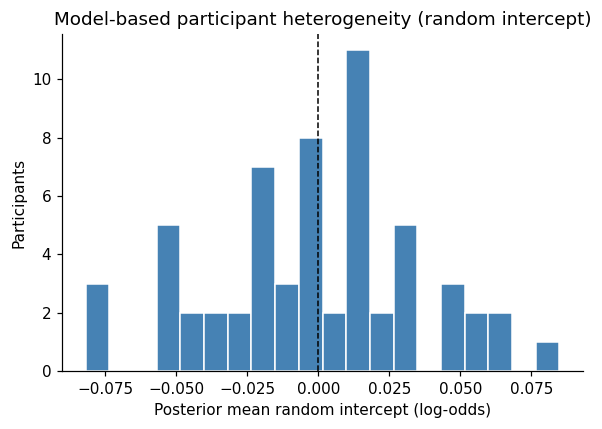

Estimated random-intercept SD (sigma_u): 0.138 log-odds units


In [ ]:
# Posterior-mean random intercept per participant: a model-based, "shrunk"
# analogue of the raw acceptance-rate histogram (Notebook 1, Section 8).
participant_effects = mixed_fit.random_effects("participant")

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.hist(participant_effects["Mean"], bins=20, color="steelblue", edgecolor="white")
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Posterior mean random intercept (log-odds)")
ax.set_ylabel("Participants")
ax.set_title("Model-based participant heterogeneity (random intercept)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "08_random_intercepts.png"))
plt.show()

sigma_u = np.exp(mixed_fit.vcp_mean[0])
print(f"Estimated random-intercept SD (sigma_u): {sigma_u:.3f} log-odds units")

**Reading the result.** The fixed-effect posterior means (top rows of the summary)
are close to the Section 5 cluster-robust logistic regression's coefficients —
reassuring, since the two models are fit in completely different ways (marginal
likelihood with a robust sandwich covariance vs. variational Bayes with a random
intercept). They did not have to match: in a logistic mixed model, fixed-effect
coefficients describe the effect for a *given* participant holding their random
intercept fixed, while Section 5's coefficients describe the *population-averaged*
effect — a well-known non-collapsibility of the logistic link. That the two are close
here indicates the random-intercept variance is not large enough to make that
distinction matter much for this dataset, which is itself a finding, not a foregone
conclusion.

The random intercept has an estimated standard deviation of $\hat\sigma_u \approx
0.14$ log-odds units. As a rough intuition: two participants one standard deviation
apart in their random intercept, everything else held equal, differ in their odds of
gambling by a factor of $e^{2 \times 0.14} \approx 1.33$ — a real, non-trivial gap
in baseline risk-taking tendency the covariates in this model do not explain. This
corroborates Section 6's conclusion, via an entirely different method, that a single
shared response probability does not adequately describe these participants.

**What this does and does not establish.**

- It does not contradict Section 6's original reasoning about what is hard to estimate
  well here. A **random-slopes** model — letting sensitivity to `gen`, `probability`, or
  `loss` vary by participant, rather than only the intercept — would ask far more of 15
  trials per domain per participant than a random intercept does, for the same reason
  Section 6 gave, and is not attempted here either. This model can say participants
  differ in overall gambling propensity, but not yet whether they differ in what drives
  it.
- **Variational Bayes is an approximation.** Mean-field VB is known to typically
  understate posterior uncertainty for variance components relative to exact inference
  (e.g. MCMC); $\hat\sigma_u$'s uncertainty here should be read as an approximate
  lower bound on the true uncertainty, not a definitive interval.
- Two methods agreeing — Section 6's overdispersion test and this random-intercept
  model — is meaningfully stronger evidence than either alone, precisely because they
  can fail in different ways. Neither, individually or together, estimates *how* any
  given participant differs, only *that* participants differ.

## 8. Gains and Losses, Revisited

Section 4 found a difference between gain- and loss-domain acceptance rates. It is
tempting to label this "loss aversion," but that specific term refers to a stronger
*value-function* response to losses than equivalent-sized gains — a claim about the
curvature/scaling of subjective value, not directly about risk-taking. The pattern
observed here is also consistent with several other, non-equivalent explanations:

- A **reflection effect** in risk attitude (the classic prospect-theory prediction:
  risk-averse for gains, risk-seeking for losses) would predict loss-domain certainty
  equivalents skewed toward the risk-*seeking* side. Section 3 found the opposite skew
  in this dataset (leaning risk-averse-consistent in the loss domain), so this specific
  explanation is not well supported here — a useful illustration that a plausible
  theoretical story does not automatically fit a given dataset, and should be checked
  against it rather than assumed.
- **Differential attention or engagement** with loss-framed trials versus gain-framed
  trials (a measurement artefact rather than a preference difference) remains a live
  possibility that the CE evidence does not rule out.
- An **order/context effect** is also possible, since gain and loss blocks were both
  present in the same session for every participant (Notebook 1, Section 5).

The data collected here cannot cleanly separate these remaining explanations from one
another. A design change — for instance, randomising which domain block a participant
sees first, or eliciting willingness-to-pay directly rather than only binary choices —
would be needed to adjudicate between them. This is flagged as a design limitation, not
resolved here.

## 9. Model Comparison

Two models are compared on their ability to predict individual choices:

- **Benchmark model**: uses only `gen`, the EV-relative generosity of the certain option
  (domain-consistent — see Section 5), with no separate information about gain/loss
  framing.
- **Full model**: adds the gain/loss domain indicator and its interaction with `gen` —
  i.e., structure motivated by the idea that preferences are not a fixed function of
  expected-value differences alone (Section 5's model).

Both are evaluated by 5-fold cross-validation, **grouped by participant** (so that no
participant's trials appear in both the training and test fold within a split — otherwise
predictive performance would be inflated by simply learning that participant's general
tendency to gamble from other trials of theirs in the training set).

In [ ]:
X_benchmark = model_df[["gen"]].values
X_full = model_df[["gen", "loss"]].copy()
X_full["gen_x_loss"] = X_full["gen"] * X_full["loss"]
X_full = X_full.values
y = model_df["gambled"].values
groups = model_df["participant_id"].values

gkf = GroupKFold(n_splits=5)
results = {"benchmark": {"acc": [], "logloss": []}, "full": {"acc": [], "logloss": []}}

for train_idx, test_idx in gkf.split(X_benchmark, y, groups):
    for name, X in [("benchmark", X_benchmark), ("full", X_full)]:
        clf = LogisticRegression()
        clf.fit(X[train_idx], y[train_idx])
        pred_proba = clf.predict_proba(X[test_idx])[:, 1]
        pred_class = clf.predict(X[test_idx])
        results[name]["acc"].append(accuracy_score(y[test_idx], pred_class))
        results[name]["logloss"].append(log_loss(y[test_idx], pred_proba, labels=[0, 1]))

cv_summary = pd.DataFrame({
    name: {"mean_accuracy": np.mean(r["acc"]), "mean_log_loss": np.mean(r["logloss"])}
    for name, r in results.items()
}).T.round(4)
print("5-fold grouped cross-validation (out-of-sample):")
print(cv_summary)

# In-sample AIC/BIC via statsmodels for a complementary view
bench_fit = smf.logit("gambled ~ gen", data=model_df).fit(disp=False)
full_fit = smf.logit("gambled ~ gen * loss", data=model_df).fit(disp=False)
print(f"\nIn-sample AIC -- benchmark: {bench_fit.aic:.1f}   full: {full_fit.aic:.1f}")
print(f"In-sample BIC -- benchmark: {bench_fit.bic:.1f}   full: {full_fit.bic:.1f}")

5-fold grouped cross-validation (out-of-sample):
           mean_accuracy  mean_log_loss
benchmark         0.6663         0.6091
full              0.6917         0.6038

In-sample AIC -- benchmark: 2153.0   full: 2131.8
In-sample BIC -- benchmark: 2164.0   full: 2153.7


**The central question** is whether adding domain-related structure improves the
statistical explanation of choices beyond what the EV-relative generosity of the
certain option (`gen`) alone provides. Here the answer leans toward "yes, modestly":
cross-validated accuracy is higher for the full model (66.6% → 69.2%), while
cross-validated log-loss — a stricter, probability-weighted score — moves only slightly
(0.609 → 0.604). In-sample, both AIC (2153.0 → 2131.8) and BIC (2164.0 → 2153.7) favour
the full model, so the two criteria agree here rather than trading off fit against
complexity in opposite directions. The gap is large enough on the standard AIC/BIC
scales to count as reasonably strong, if not overwhelming, support for the richer
specification. Taken together, this is evidence that something about the gain/loss
framing matters for predicting choices beyond the certain option's raw generosity
(consistent with, though per Section 8 not proof of, subjective preference-related
structure) — a real improvement, but one that should be read alongside the log-loss
result: even the full model still leaves most of the outcome unexplained, which is
expected for a study of noisy individual choices and is examined further in Section 11.
Section 10 asks the same question from a different, theory-first angle.

## 10. A Structural, Theory-Based Choice Model

Sections 5-9 all use **reduced-form** models: flexible in the design variables
(probability, the certain option's generosity, domain) but agnostic about *why* those
variables move choice probability the way they do. Notebook 1, Section 3 laid out a
specific theoretical mechanism instead — a value function with diminishing sensitivity
and loss aversion, a probability-weighting function, and a logistic choice rule — and
that mechanism, not a generic logit-linear specification, is what actually generated the
data (`src/analysis_helpers.py`). This section estimates that theoretical model's
parameters directly from the observed choices by maximum likelihood, rather than only
asking whether a flexible reduced-form model fits reasonably well.

$$V(\text{risky}) = w(p;\gamma)\, v(x; \alpha, \lambda), \qquad V(\text{certain}) = v(c; \alpha, \lambda), \qquad P(\text{choose risky}) = \text{logit}^{-1}\big(\beta\,[\,V(\text{risky}) - V(\text{certain})\,]\big)$$

with $v(\cdot)$ and $w(\cdot)$ the same value and probability-weighting functions the
simulator uses (`value_fn`, `prob_weight`). Two points are worth stating before fitting:

- **Identification.** The simulator's choice rule has two separate parameters — a
  consistency parameter $k$ and a noise scale — but they enter every choice probability
  only through their ratio. No amount of choice data can separate them, so this model
  has a single composite sensitivity parameter $\beta$ instead of trying to recover
  both (see the module note in `analysis_helpers.py`). Fitting an unidentified pair
  would not fail loudly; it would silently return an arbitrary point along a ridge of
  equally good fits, which is precisely why this is worth stating rather than
  discovering by accident.
- **This model is estimated from choices alone**, using the theoretical functional form
  from Notebook 1 but not the simulator's true parameter values, which — as throughout
  this project — are never available to this analysis.

In [ ]:
from analysis_helpers import fit_structural_model, structural_choice_probability

# NOTE: `model_df["loss"]` was overwritten in Section 5 to a 0/1 domain indicator, so
# the risky outcome amount is reconstructed from `substantive`'s original gain/loss
# magnitude columns, not from model_df, to avoid silently mixing the two.
model_df["risky_outcome"] = np.where(substantive.domain == "gain", substantive.gain, -substantive.loss)

struct_fit = fit_structural_model(model_df)
alpha_hat, lam_hat, gamma_hat, beta_hat = struct_fit.x
print(f"alpha (curvature)          = {alpha_hat:.3f}")
print(f"lambda (loss aversion)     = {lam_hat:.3f}")
print(f"gamma (probability weight) = {gamma_hat:.3f}")
print(f"beta (choice sensitivity)  = {beta_hat:.3f}")
print(f"\nNegative log-likelihood: {struct_fit.nll:.1f}   AIC: {struct_fit.aic:.1f}   BIC: {struct_fit.bic:.1f}")

# Robustness of the optimum: refit from several dispersed starting points
starts = [(1.0, 1.0, 1.0, 0.1), (0.5, 3.0, 0.5, 0.5), (1.2, 1.0, 1.0, 2.0)]
print("\nRefits from dispersed starting points (sanity check against local optima):")
for s in starts:
    r = fit_structural_model(model_df, x0=s)
    print(f"  start={s} -> alpha,lambda,gamma,beta={np.round(r.x, 3)}, NLL={r.fun:.2f}")

alpha (curvature)          = 0.874
lambda (loss aversion)     = 1.346
gamma (probability weight) = 0.816
beta (choice sensitivity)  = 0.169

Negative log-likelihood: 1060.7   AIC: 2129.4   BIC: 2151.3

Refits from dispersed starting points (sanity check against local optima):
  start=(1.0, 1.0, 1.0, 0.1) -> alpha,lambda,gamma,beta=[0.874 1.346 0.816 0.169], NLL=1060.70
  start=(0.5, 3.0, 0.5, 0.5) -> alpha,lambda,gamma,beta=[0.874 1.346 0.816 0.169], NLL=1060.70
  start=(1.2, 1.0, 1.0, 2.0) -> alpha,lambda,gamma,beta=[0.874 1.346 0.816 0.169], NLL=1060.70


**A single, stable optimum.** Refitting from several widely dispersed starting points
converges to the same parameters and the same likelihood to two decimal places — some
reassurance this is a genuine maximum, not an artefact of where the optimiser started (a
real risk with a non-convex likelihood like this one).

**Reading the fitted parameters, with the usual cautions.** $\hat\alpha \approx
0.87$ indicates diminishing sensitivity to outcome size, consistent with the
concave/convex value-function shape assumed in Notebook 1, Section 3, and broadly in
line with typically published estimates (e.g. Tversky & Kahneman, 1992). $\hat\lambda
\approx 1.35$ indicates the loss branch of the value function is weighted more heavily
than the gain branch — loss aversion **in the specific, value-function sense that
Section 8 noted the reduced-form model could not isolate**, since only this structural
model separates a "loss aversion" parameter from a "probability weighting" parameter
within one estimated model. $\hat\gamma \approx 0.82$ indicates only mild
probability weighting relative to $\gamma = 1$ (no weighting).

**This does not resolve Section 8's identification problem — it relocates it.** Section
8 explained that the gain/loss acceptance gap could reflect loss aversion, a reflection
effect, an attention artefact, or some mixture, and that the available trial data cannot
adjudicate between them. Fitting $\hat\lambda$ and $\hat\gamma$ *inside one assumed
functional form* produces a specific, named decomposition, but that decomposition is
only as credible as the functional form itself, which is assumed, not tested, here. A
structural model is a lens for interpreting a pattern already established
descriptively, not a new source of identifying data.

**A pooled estimate, over a population Sections 6-7 show is heterogeneous.** These are
single "representative-agent" parameters fit to all 1,768 pooled trials. Sections 6 and
7 established that participants are not identical; averaging a genuinely nonlinear
choice model over a heterogeneous population does not generally recover "the parameters
of the average participant" — a well-known aggregation issue in nonlinear models, where
the model of an average agent and the average of individual agents' models are not the
same object. Individual- or hierarchically-pooled structural estimates would address
this directly, but, consistent with Sections 6-7's sample-size reasoning, are not
attempted with 15 trials per domain per participant.

5-fold grouped cross-validation, now including the structural model:
            mean_accuracy  mean_log_loss
benchmark          0.6663         0.6091
full               0.6917         0.6038
structural         0.6917         0.6115

In-sample AIC -- benchmark: 2153.0  full: 2131.8  structural: 2129.4
In-sample BIC -- benchmark: 2164.0  full: 2153.7  structural: 2151.3


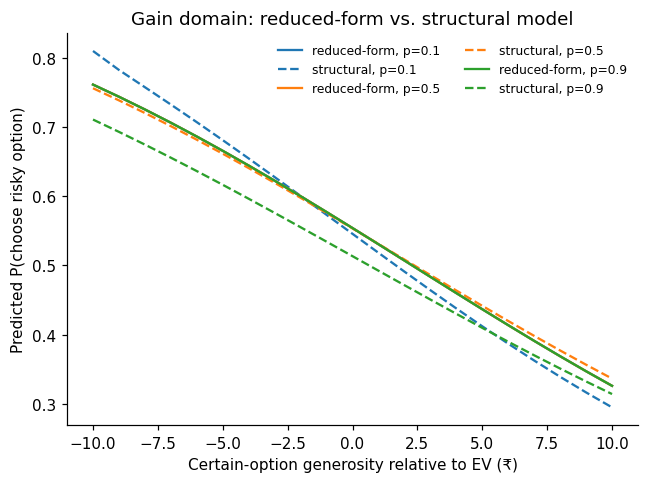

In [ ]:
# Extend the Section 9 cross-validated comparison with the structural model, refit on
# each training fold using the exact same GroupKFold splits as benchmark/full.
results["structural"] = {"acc": [], "logloss": []}
for train_idx, test_idx in gkf.split(X_benchmark, y, groups):
    train_df, test_df = model_df.iloc[train_idx], model_df.iloc[test_idx]
    fold_fit = fit_structural_model(train_df)
    pred_proba = structural_choice_probability(
        fold_fit.x, test_df.probability.values, test_df.certain_amount.values, test_df.risky_outcome.values
    )
    pred_proba = np.clip(pred_proba, 1e-10, 1 - 1e-10)
    results["structural"]["acc"].append(accuracy_score(y[test_idx], (pred_proba > 0.5).astype(int)))
    results["structural"]["logloss"].append(log_loss(y[test_idx], pred_proba, labels=[0, 1]))

cv_summary3 = pd.DataFrame({
    name: {"mean_accuracy": np.mean(r["acc"]), "mean_log_loss": np.mean(r["logloss"])}
    for name, r in results.items()
}).T.round(4)
print("5-fold grouped cross-validation, now including the structural model:")
print(cv_summary3)
print(f"\nIn-sample AIC -- benchmark: {bench_fit.aic:.1f}  full: {full_fit.aic:.1f}  structural: {struct_fit.aic:.1f}")
print(f"In-sample BIC -- benchmark: {bench_fit.bic:.1f}  full: {full_fit.bic:.1f}  structural: {struct_fit.bic:.1f}")

# Predicted-probability comparison at the actual design points (Section 5 style)
grid = pd.DataFrame([
    {"probability": p, "gen": g, "loss": 0, "certain_amount": 100 * p + g, "risky_outcome": 100.0}
    for p in [0.1, 0.5, 0.9] for g in np.linspace(-10, 10, 21)
])
grid["reduced_pred"] = full_fit.predict(grid)
grid["structural_pred"] = structural_choice_probability(
    struct_fit.x, grid.probability.values, grid.certain_amount.values, grid.risky_outcome.values
)

fig, ax = plt.subplots(figsize=(6, 4.5))
colors = {0.1: "tab:blue", 0.5: "tab:orange", 0.9: "tab:green"}
for p in [0.1, 0.5, 0.9]:
    s = grid[grid.probability == p]
    ax.plot(s.gen, s.reduced_pred, color=colors[p], label=f"reduced-form, p={p}")
    ax.plot(s.gen, s.structural_pred, color=colors[p], ls="--", label=f"structural, p={p}")
ax.set_xlabel("Certain-option generosity relative to EV (₹)")
ax.set_ylabel("Predicted P(choose risky option)")
ax.set_title("Gain domain: reduced-form vs. structural model")
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "09_structural_vs_reduced.png"))
plt.show()

**The two models agree closely at the design points actually tested, and diverge
mostly on the criterion, not the substance.** Restricted to the certain-amount offsets
actually used in this experiment ($\text{gen} \in \{-10, 0, 10\}$), the two models'
predicted probabilities differ by at most about 5 percentage points — visible in the
plot above as near-overlapping solid/dashed pairs. Cross-validated accuracy is
identical to three significant figures (69.2% for both), and in-sample AIC/BIC both
slightly favour the structural model, despite it having the same number of free
parameters (4) as the reduced-form "full" model and none of them chosen after looking
at the data — every parameter corresponds to a named theoretical quantity fixed in
advance by the functional form in Notebook 1. Cross-validated log-loss, a stricter
proper scoring rule, points the other way by a small margin (full: 0.604, structural:
0.612) — a reminder that in-sample criteria (AIC/BIC) and out-of-sample criteria
(cross-validated log-loss) need not agree, particularly at this sample size, and both
should be reported rather than quoting whichever favours a preferred model.

(The reduced-form lines for the three probability levels sit almost on top of
each other because the Section 9 "full" model, by design, does not include
`probability` as a predictor at all -- Section 5 already found its coefficient
indistinguishable from zero once `gen` and `loss` were included. The structural
model's small p-dependence comes entirely from probability weighting, $w(p;\gamma)$,
which is a feature of the theoretical mechanism, not an extra fitted flexibility.)

Taken together, this is modest, honest evidence that the theoretical mechanism is
*consistent with* the observed choice pattern — a genuinely flexible atheoretical
alternative gains it essentially nothing in predictive terms — but not proof that the
mechanism is correct, since a sharper test would need predictions genuinely outside the
range this design tested (e.g. a different stake size), which this dataset cannot
provide.

## 11. Model Diagnostics

A calibration check: among trials where the full model predicts a given probability of
gambling, does the observed frequency of gambling actually match?

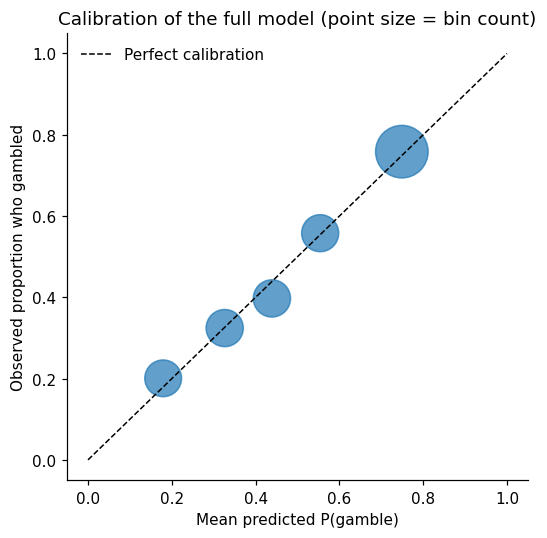

Participant-level mean residual: min=-0.166, max=0.167, sd=0.074
(A residual spread well above zero confirms the model, which has no participant-specific term, leaves systematic individual variation unexplained -- expected, and consistent with Section 6.)


In [ ]:
model_df["pred_full"] = full_fit.predict(model_df)
model_df["bin"] = pd.cut(model_df.pred_full, bins=np.linspace(0, 1, 11), include_lowest=True)
calib = model_df.groupby("bin", observed=True).agg(
    predicted=("pred_full", "mean"), observed=("gambled", "mean"), n=("gambled", "size")
).dropna()

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.scatter(calib.predicted, calib.observed, s=calib.n * 2, alpha=0.7)
ax.set_xlabel("Mean predicted P(gamble)")
ax.set_ylabel("Observed proportion who gambled")
ax.set_title("Calibration of the full model (point size = bin count)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "07_calibration.png"))
plt.show()

# Participant-level mean residual: unexplained heterogeneity the model doesn't capture
model_df["resid"] = model_df.gambled - model_df.pred_full
part_resid = model_df.groupby("participant_id").resid.mean().sort_values()
print(f"Participant-level mean residual: min={part_resid.min():.3f}, "
      f"max={part_resid.max():.3f}, sd={part_resid.std():.3f}")
print("(A residual spread well above zero confirms the model, which has no participant-"
      "specific term, leaves systematic individual variation unexplained -- expected, "
      "and consistent with Section 6.)")

## 12. Robustness

Two targeted checks, chosen because they speak directly to decisions made earlier in the
pipeline, rather than an unfocused battery of alternative specifications:

1. **Excluding low-attention participants.** Refit the Section 5 model after dropping
   participants who gambled on *both* dominance-check trials (an unambiguous marker of
   inattentive or random responding), and compare coefficients.
2. **Alternative treatment of the certain-amount variable.** Refit using the raw
   `certain_amount` (still domain-consistent — a higher certain amount is always better,
   whether it's a smaller loss or a larger gain) in place of the EV-relative `gen`, to
   check whether netting out the lottery's expected value (as `gen` does) versus using
   the raw rupee amount directly changes the qualitative conclusion about the domain
   interaction.

In [ ]:
low_attention = (dom_checks.groupby("participant_id").gambled.mean() == 1.0)
low_attention_ids = low_attention[low_attention].index.tolist()
print(f"Participants gambling on both dominance checks: {len(low_attention_ids)} of "
      f"{df.participant_id.nunique()}")

robust_df = model_df[~model_df.participant_id.isin(low_attention_ids)]
fit_robust = smf.logit("gambled ~ probability + gen + loss "
                        "+ probability:loss + gen:loss", data=robust_df
                       ).fit(cov_type="cluster", cov_kwds={"groups": robust_df["participant_id"]}, disp=False)

fit_altvar = smf.logit("gambled ~ probability + certain_amount + loss "
                        "+ probability:loss + certain_amount:loss", data=model_df
                       ).fit(cov_type="cluster", cov_kwds={"groups": model_df["participant_id"]}, disp=False)

comparison = pd.DataFrame({
    "main_model": fit.params,
    "excl_low_attention": fit_robust.params.reindex(fit.params.index),
}).round(3)
print("\nCoefficient comparison (main vs. low-attention-excluded):")
print(comparison)

print(f"\ngen:loss interaction sign, main model:                       {np.sign(fit.params['gen:loss']):.0f}")
print(f"certain_amount:loss interaction sign, alt.-variable model:   {np.sign(fit_altvar.params['certain_amount:loss']):.0f}")

Participants gambling on both dominance checks: 1 of 60

Coefficient comparison (main vs. low-attention-excluded):
                  main_model  excl_low_attention
Intercept              0.157               0.147
probability            0.119               0.142
gen                   -0.094              -0.094
loss                  -0.619              -0.616
probability:loss       0.312               0.287
gen:loss              -0.034              -0.034

gen:loss interaction sign, main model:                       -1
certain_amount:loss interaction sign, alt.-variable model:   -1


Coefficients move only modestly under either check. Both specifications use a
domain-consistent measure of "how good the certain option is" (Section 5's note above),
so, unlike a comparison against the raw pre-sign design offset, the loss-interaction
sign is expected to agree across the two here — and it does. This does not mean the
model is "correct" in any strong sense — only that the main conclusions are not
obviously an artefact of the specific attention-exclusion rule or the choice between an
EV-relative and a raw-rupee measure of the certain option.

## 13. Interpretation

**What the data show.** Gamble acceptance in this sample declines as the certain
alternative becomes more generous (Section 1, Notebook 1 Section 8); acceptance rates
differ, on average, between the gain and loss domains (Section 4); participant-level
acceptance rates are more dispersed than 15-trial sampling noise alone would produce, a
conclusion reached independently by a simulation-based test (Section 6, $p = 0.001$) and
a random-intercept model (Section 7, $\hat\sigma_u \approx 0.14$); and a minority of
individual choice triples show internally inconsistent (non-monotonic) patterns,
alongside a majority showing a single clean switch (Section 2).

**What the reduced-form model suggests**, conditional on the logistic specification and
its assumptions holding: choices respond systematically to the certain option's
generosity relative to the EV, and that sensitivity is itself somewhat stronger in the
loss domain than the gain domain (Section 5) — a specific, falsifiable claim, not just
"gains and losses differ somehow." Probability's own coefficient, once generosity and
domain are accounted for, was not distinguishable from zero in this sample (Section 5) —
a reminder that a variable can matter descriptively (Section 1) without carrying
independent weight once correlated design variables are modelled jointly. Domain-related
structure adds real, if not dramatic, out-of-sample predictive value beyond the certain
option's raw generosity, with AIC and BIC agreeing on that direction (Section 9).

**What the structural model adds.** A theoretical model with the same number of free
parameters as the reduced-form model, but none chosen after looking at the data, matches
its cross-validated accuracy and slightly improves on its AIC/BIC, though cross-validated
log-loss points the other way by a small margin (Section 10). Read together, this is
evidence consistent with the value-and-probability-weighting mechanism generating the
observed pattern, though not, on its own, proof of it. The fitted curvature and
loss-aversion parameters are broadly in line with typical published estimates, but are
pooled across a population Sections 6-7 show is heterogeneous, and only decompose the
gain/loss gap under an assumed functional form rather than independently resolving the
identification question raised in Section 8.

**What remains uncertain.** Whether the gain/loss difference reflects loss aversion
specifically, a reflection effect in risk attitude, an attention/measurement artefact, or
some mixture, cannot be determined from this design alone (Section 8); the structural
model in Section 10 offers one internally consistent way of naming a decomposition, not
an independent resolution. *How* preferences vary across individuals is now supported by
two convergent pieces of evidence that they do vary (Sections 6-7), but separate
per-participant parameters, as opposed to the population-average relationships modelled
above, remain unreliable at this sample size and are not estimated. And because the
entire dataset is simulated, none of the above is a claim about real human behaviour — it
is a demonstration that the statistical methods, applied to data with these properties,
would recover a coherent, appropriately-hedged picture.

## 14. Limitations

- **The data are simulated, not collected from real participants.** This is the single
  most important limitation and qualifies every result in this notebook.
- **Sample size.** 60 simulated participants and 15 substantive trials per
  domain/participant is enough to estimate population-average relationships and even a
  simple random-intercept variance component (Section 7), but not random slopes or
  reliable individual-level preference profiles, structural or otherwise.
- **Convenience-style sampling**, in a real deployment, would limit external validity to
  whatever population was actually recruited.
- **Hypothetical (or, here, simulated) rather than real, incentivised choices.** Real
  monetary stakes are known to affect how carefully people respond in this kind of task;
  this design does not resolve that question.
- **Framing and order effects** (Section 8) are not separated from genuine gain/loss
  preference differences.
- **Measurement error / imperfect attention.** A minority of choices are internally
  inconsistent (Section 2); this analysis treats that as noise rather than as evidence of
  a genuinely non-monotonic preference, which is itself an assumption.
- **A narrow range of monetary outcomes** (single magnitude of ₹100) means nothing here
  speaks to how preferences might change at very different stake sizes.
- **Model assumptions.** The reduced-form logistic specification assumes a particular
  functional form connecting objective trial features to choice probability; Section
  11's diagnostics suggest it is reasonably calibrated but not perfect. The structural
  model (Section 10) assumes a stronger, specific theoretical form and estimates it
  pooled across participants. Both leave the random-intercept-scale heterogeneity
  quantified in Section 7 unexplained, since neither includes participant-specific
  parameters.
- **Representation versus measurement.** Nothing in this notebook measures a person's
  "true" utility function on some absolute scale. Certainty equivalents, reduced-form
  coefficients, and structural parameter estimates are all statistical summaries of
  choice patterns, filtered through modelling assumptions — evidence about preferences,
  not direct readings of them.

## 15. Final Conclusions

Returning directly to the research questions posed in Notebook 1, Section 4:

1. **Systematic risk preferences?** Yes, in the specific sense that acceptance of the
   risky option responds systematically and predictably to how the certain alternative
   compares to the lottery's expected value (Sections 1, 5), and a theoretically
   motivated model of that response performs at least as well as a flexible atheoretical
   one (Section 10).
2. **Heterogeneity?** Yes, on two independent lines of evidence: participant-level
   acceptance rates are more dispersed than a simulated sampling-noise null would predict
   (Section 6, one-sided $p = 0.001$), and a random-intercept choice model estimates a
   non-negligible participant-level variance component after conditioning on the same
   trial features (Section 7). Individual preference *parameters*, as opposed to this
   population-level statement that heterogeneity exists, are not separately estimable at
   this sample size.
3. **Does probability influence choices?** Descriptively, acceptance rates vary somewhat
   across probability levels (Section 1). Once the certain option's generosity and the
   gain/loss domain are accounted for in the joint model, however, probability's own
   coefficient was not statistically distinguishable from zero (Section 5) — a caution
   against over-interpreting the univariate pattern.
4. **Are gains and losses treated differently?** Acceptance rates and estimated
   certainty equivalents differ between domains (Sections 3, 4), and the structural
   model's separate curvature and loss-aversion parameters offer one internally
   consistent decomposition (Section 10) — but the specific mechanism (loss aversion vs.
   reflection effect vs. measurement artefact) is not identified by this design (Section
   8), and the structural decomposition is conditional on an assumed functional form
   rather than a resolution of that identification problem.
5. **How consistent are individual choices?** Mostly: just over half of triples show a
   clean single switch and roughly 79% of determinate triples are internally consistent
   with a single-threshold rule; a substantive minority (about a fifth) show reversals
   (Section 2).
6. **How well does a statistical model explain behaviour?** Reasonably calibrated in
   aggregate (Section 11). Adding domain-related structure improves both cross-validated
   accuracy and in-sample AIC/BIC over a benchmark built only on the certain option's
   generosity (Section 9); a structural model built from theory rather than flexible
   interaction terms matches that improved accuracy using the same number of parameters,
   though the two model families do not agree on every criterion (Section 10).
   Substantial participant-level variation remains unexplained by either model (Sections
   7, 11).
7. **What can reasonably be inferred about subjective preferences?** That observed
   choices carry *statistical evidence* of systematic, patterned responses to
   probability, outcome size, and domain; that this evidence varies across individuals in
   a way that exceeds sampling noise, on two independent tests; and that a specific,
   parsimonious theoretical mechanism for generating those responses is at least
   consistent with, and not contradicted by, the observed choice patterns.
8. **What cannot be inferred?** Any individual's exact utility function; a clean
   mechanistic explanation for the gain/loss difference, structural decomposition
   notwithstanding; or, most fundamentally, any claim about real human decision-makers at
   all, since the entire empirical exercise here rests on simulated data used to
   demonstrate the statistical approach.